In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from pandas import DataFrame

C:\Users\pierr\PycharmProjects\Deep-Learning-Exercices\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Configure device with cuda

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
def seed_everything(seed=42):
	np.random.seed(seed)
	torch.manual_seed(seed)
	if torch.cuda.is_available():
		torch.cuda.manual_seed_all(seed)
seed_everything()

In [3]:
# Load the Bike Sharing dataset
data_day: DataFrame = pd.read_csv("../data/bike+sharing+dataset/day.csv", parse_dates=["dteday"])
data_hour: DataFrame = pd.read_csv("../data/bike+sharing+dataset/hour.csv", parse_dates=["dteday"])
# Prefer data_hour for more granular analysis

In [6]:
data_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [7]:
data_hour.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[us]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-null  int64

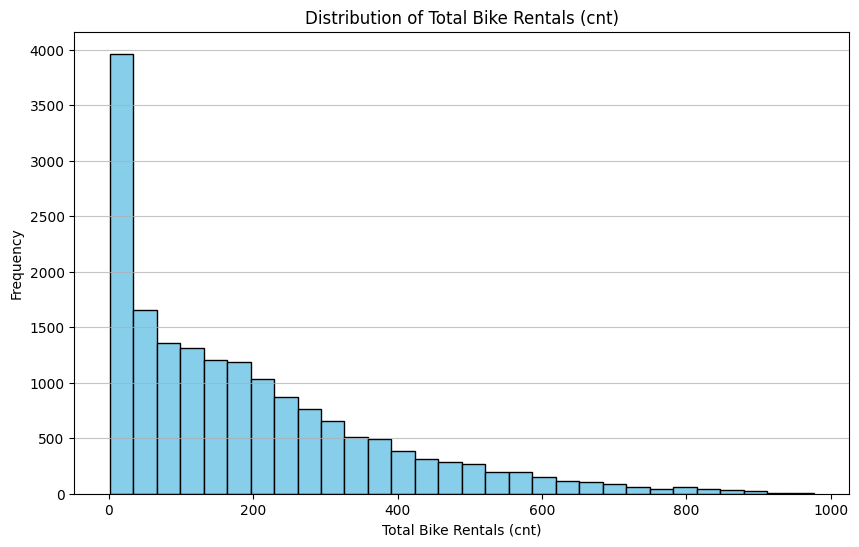

In [10]:
# Plot the distribution of the target variable 'cnt' (total bike rentals)
plt.figure(figsize=(10, 6))
plt.hist(data_hour["cnt"], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of Total Bike Rentals (cnt)")
plt.xlabel("Total Bike Rentals (cnt)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()

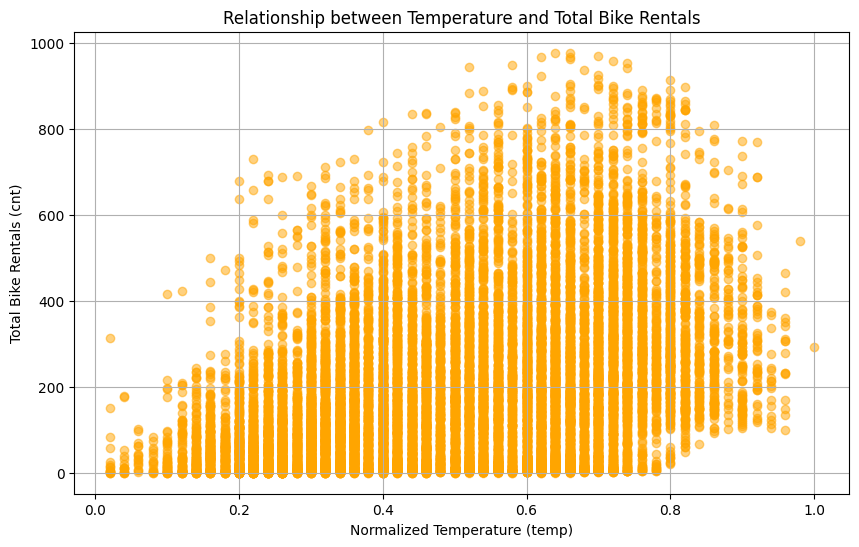

In [11]:
# Plot the relationship between 'temp' (normalized temperature) and 'cnt' (total bike rentals)
plt.figure(figsize=(10, 6))
plt.scatter(data_hour["temp"], data_hour["cnt"], alpha=0.5, color="orange")
plt.title("Relationship between Temperature and Total Bike Rentals")
plt.xlabel("Normalized Temperature (temp)")
plt.ylabel("Total Bike Rentals (cnt)")
plt.grid()